# **Fraud Analysis - Load and Clean Data**

## Objectives

* Load and clean the raw fraud transactions dataset ahead of hypothesis testing.

## Inputs

* Data/raw/transactions.csv 

## Outputs

* Data/cleaned/cleaned_transactions.csv 

## Additional Comments

* All cleaning steps and the reasoning behind them are documented in Section 2 below.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/Fraud_Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/Fraud_Analysis'

In [12]:
# Importing the libraries I will be using

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('Data_set/Raw_Data/synthetic_fraud_dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


# Data Exploration

## Data Set Size

The shape of the dataset is checked first, to establish how many transaction records and how many
variables are being worked with.

In [14]:
df.shape  # Display the shape of the DataFrame (rows, columns)

(50000, 21)

## Column Names

The full list of column names is reviewed to identify which variables exist and which are likely
to be relevant to the hypotheses being tested later in the project.

In [15]:
df.columns  # Display the column names of the DataFrame

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label'],
      dtype='object')

## Data Types and Non-Null Counts

df.info() is used to check the data type of each column and confirm whether any nulls are
present. This is also the first opportunity to notice anything unusual - for example, columns
that are numeric but behave more like categories, or object columns that may later need encoding.

In [16]:
df.info()  # Display a concise summary of the DataFrame, including the number of non-null entries and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

## Descriptive Stats

Summary statistics are generated for all numeric columns. This gives an initial sense of scale
and spread - minimum, maximum, mean, and quartiles - for every numeric variable in the dataset,
ahead of narrowing in on specific columns later.

In [17]:
df.describe().round(2)  # Display summary statistics for the numeric columns in the DataFrame

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,99.41,50294.07,0.05,0.1,7.49,255.27,2.00,120.00,2499.16,0.50,0.30,0.32
std,98.69,28760.46,0.22,0.3,4.04,141.38,1.41,68.99,1442.01,0.29,0.46,0.47
min,0.00,500.48,0.00,0.0,1.00,10.00,0.00,1.00,0.25,0.00,0.00,0.00
25%,28.68,25356.00,0.00,0.0,4.00,132.09,1.00,60.00,1256.50,0.25,0.00,0.00
50%,69.66,50384.43,0.00,0.0,7.00,256.08,2.00,120.00,2490.78,0.50,0.00,0.00
75%,138.85,75115.14,0.00,0.0,11.00,378.03,3.00,180.00,3746.40,0.75,1.00,1.00
max,1174.14,99998.31,1.00,1.0,14.00,500.00,4.00,239.00,4999.93,1.00,1.00,1.00


## Distinct Value Counts

The number of unique values per column is checked next. This distinguishes genuinely continuous
numeric columns (many distinct values) from categorical or low-cardinality columns (a handful of
repeated values), which informs how each column should be treated later - for example, which
columns are suited to .describe() versus .value_counts().

In [18]:
df.nunique().sort_values()

Previous_Fraudulent_Activity        2
Is_Weekend                          2
IP_Address_Flag                     2
Fraud_Label                         2
Device_Type                         3
Transaction_Type                    4
Card_Type                           4
Authentication_Method               4
Location                            5
Merchant_Category                   5
Failed_Transaction_Count_7d         5
Daily_Transaction_Count            14
Card_Age                          239
User_ID                          8963
Risk_Score                       9931
Transaction_Amount              21763
Avg_Transaction_Amount_7d       31420
Transaction_Distance            47546
Timestamp                       47724
Account_Balance                 49867
Transaction_ID                  50000
dtype: int64

---

# Data Cleaning Section

This section documents every cleaning action taken on the dataset, along with the reasoning
behind it. Where the data was already found to be clean (for example, no duplicate rows), this is
stated explicitly rather than omitted, since verifying data quality is itself part of the cleaning
process and not only the corrections that follow from it.

## Duplicate Records

Two checks are carried out: one for fully duplicated rows across the dataset, and a second
specifically on the Transaction_ID column. A duplicate row is a general data quality issue, but a
duplicate transaction ID would indicate the same transaction appearing twice, which could distort
any fraud rate calculated later.

In [23]:
df.duplicated().sum()  # Check for fully duplicated rows

0

In [22]:
df['Transaction_ID'].duplicated().sum()  # Check for duplicate transaction IDs specifically

0

No duplicate rows or duplicate transaction IDs were found. No action was required, and this
result is recorded as evidence that the check was carried out.

## Checking For Missing Values

df.isnull().sum() was used to confirm any null values.

In [25]:
df.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

No missing values were found in any column.

## Hidden Placeholder Values In Catogorical Columns

df.info() above confirmed there are no literal null values in the dataset, and df.nunique()
confirmed a small, fixed set of categories for each categorical column. It is still worth checking
directly for placeholder strings that function as missing data without being registered as NaN by
pandas - for example, a value such as 'Unknown', 'N/A', or an empty string. Each categorical
column is checked for this explicitly, rather than assuming the clean category counts above rule
it out.

In [26]:
cat_cols = ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
placeholder_values = ['unknown', 'n/a', 'na', 'none', 'null', '', '-', '?']

for col in cat_cols:
    values_lower = df[col].astype(str).str.strip().str.lower()
    hits = values_lower.isin(placeholder_values).sum()
    print(f"{col}: {hits} placeholder-like values")

Transaction_Type: 0 placeholder-like values
Device_Type: 0 placeholder-like values
Location: 0 placeholder-like values
Merchant_Category: 0 placeholder-like values
Card_Type: 0 placeholder-like values
Authentication_Method: 0 placeholder-like values


No placeholder-like values were found in any categorical column. No action was required.

## Outlier Detection

Outliers are checked using the interquartile range (IQR) method, applied across all numeric
columns in the dataset - not only the two tied to the hypotheses under investigation
(Transaction_Distance and Failed_Transaction_Count_7d), but also the remaining numeric
columns (Transaction_Amount, Account_Balance, Daily_Transaction_Count,
Avg_Transaction_Amount_7d, Card_Age, Risk_Score), since these are still used as features in
the Machine Learning notebook later, even though they are not part of a specific hypothesis.

In [27]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower_bound) | (series > upper_bound)).sum()

outlier_check_cols = ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count',
                      'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age',
                      'Transaction_Distance', 'Risk_Score']

for col in outlier_check_cols:
    print(f"{col}: {iqr_outlier_count(df[col])} potential outliers")

Transaction_Amount: 2260 potential outliers
Account_Balance: 0 potential outliers
Daily_Transaction_Count: 0 potential outliers
Avg_Transaction_Amount_7d: 0 potential outliers
Failed_Transaction_Count_7d: 0 potential outliers
Card_Age: 0 potential outliers
Transaction_Distance: 0 potential outliers
Risk_Score: 0 potential outliers


In [28]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

Only Transaction_Amount shows any IQR outliers - 2,260 rows, 4.52% of the dataset. Every
other numeric column, including both hypothesis columns, comes back with zero outliers by this
method.

Flagged values were reviewed and kept rather than removed. An unusually large transaction amount
could reflect genuine fraudulent activity rather than a data entry error, and for the hypotheses
concerning transaction behaviour, extreme values are part of the pattern being investigated -
removing them would remove evidence the analysis depends on.

## Reviewing the Target Variable

Unlike the target variable in Project 1, which was stored as text ('Existing Customer' /
'Attrited Customer') and needed encoding into a binary column, Fraud_Label in this dataset is
already stored as a binary integer (0 = not fraud, 1 = fraud), confirmed in the Data Types check
in Section 1. No encoding step is required here.

Fraud_Label
0    0.679
1    0.321
Name: proportion, dtype: float64

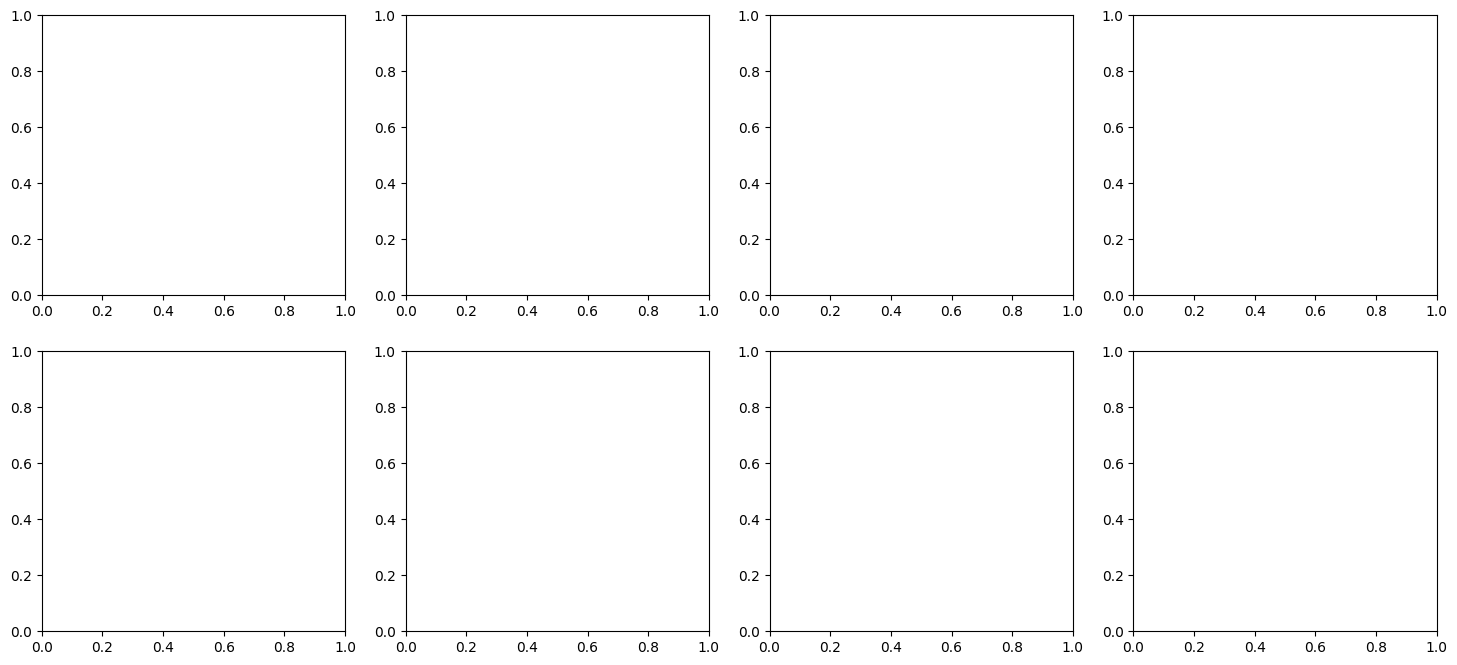

In [29]:
df['Fraud_Label'].value_counts(normalize=True).round(3)

Approximately 68% of transactions are not fraudulent and 32% are fraudulent. This is a
moderate class imbalance, not the severe imbalance often assumed in fraud detection datasets. It
does not require correction for the descriptive and statistical work carried out in this project,
but it is noted here as it should be considered when interpreting results in later sections.

## Data TYpe Conversion

A chi-square test (used for H2 and H3 in the next notebook) needs categorical or binary data; a
t-test and correlation (used for H4 and H5) need genuinely numeric data. The data types checked in
Section 1 already confirmed Fraud_Label, Previous_Fraudulent_Activity, and IP_Address_Flag
are stored as integers, and Transaction_Distance and Failed_Transaction_Count_7d are stored as
numeric types - all correct as they stand. Authentication_Method is stored as text; it is
converted to a category type below, since it represents a small, fixed set of repeated values and
is used repeatedly in grouping operations for H2.

In [30]:
df_clean = df.copy()

df_clean['Authentication_Method'] = df_clean['Authentication_Method'].astype('category')
df_clean['Authentication_Method'].dtype

CategoricalDtype(categories=['Biometric', 'OTP', 'PIN', 'Password'], ordered=False, categories_dtype=object)

## Flagging Outliers

The Transaction_Amount outliers identified above are flagged with a new True/False column,
rather than removed, so the information is preserved without letting a handful of extreme values
distort any averages calculated later.

In [31]:
q1 = df_clean['Transaction_Amount'].quantile(0.25)
q3 = df_clean['Transaction_Amount'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

df_clean['Is_Outlier_Amount'] = df_clean['Transaction_Amount'] > upper_bound
df_clean['Is_Outlier_Amount'].value_counts()

Is_Outlier_Amount
False    47740
True      2260
Name: count, dtype: int64

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [20]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)